### Exercise 9.1: Bit Error Rate (BER) for BPSK Modulation

*Source:* Michael Rice, *Digital Communications: A Discrete-Time Approach*, Second Edition, 2020. Problem 6.1.

#### Question 9.1a:
Show that the probability of bit error for BPSK with additive white Gaussian noise (AWGN) is $P_b = Q(\sqrt{\frac{2 E_b}{N_0}})$, where $E_b$ is the average energy per bit, and $N_0$ is the variance (power) of AWGN.

*ANSWER:*

*Hint:* Refer to section 6.1.2 *Probability of Error*, in the above book.

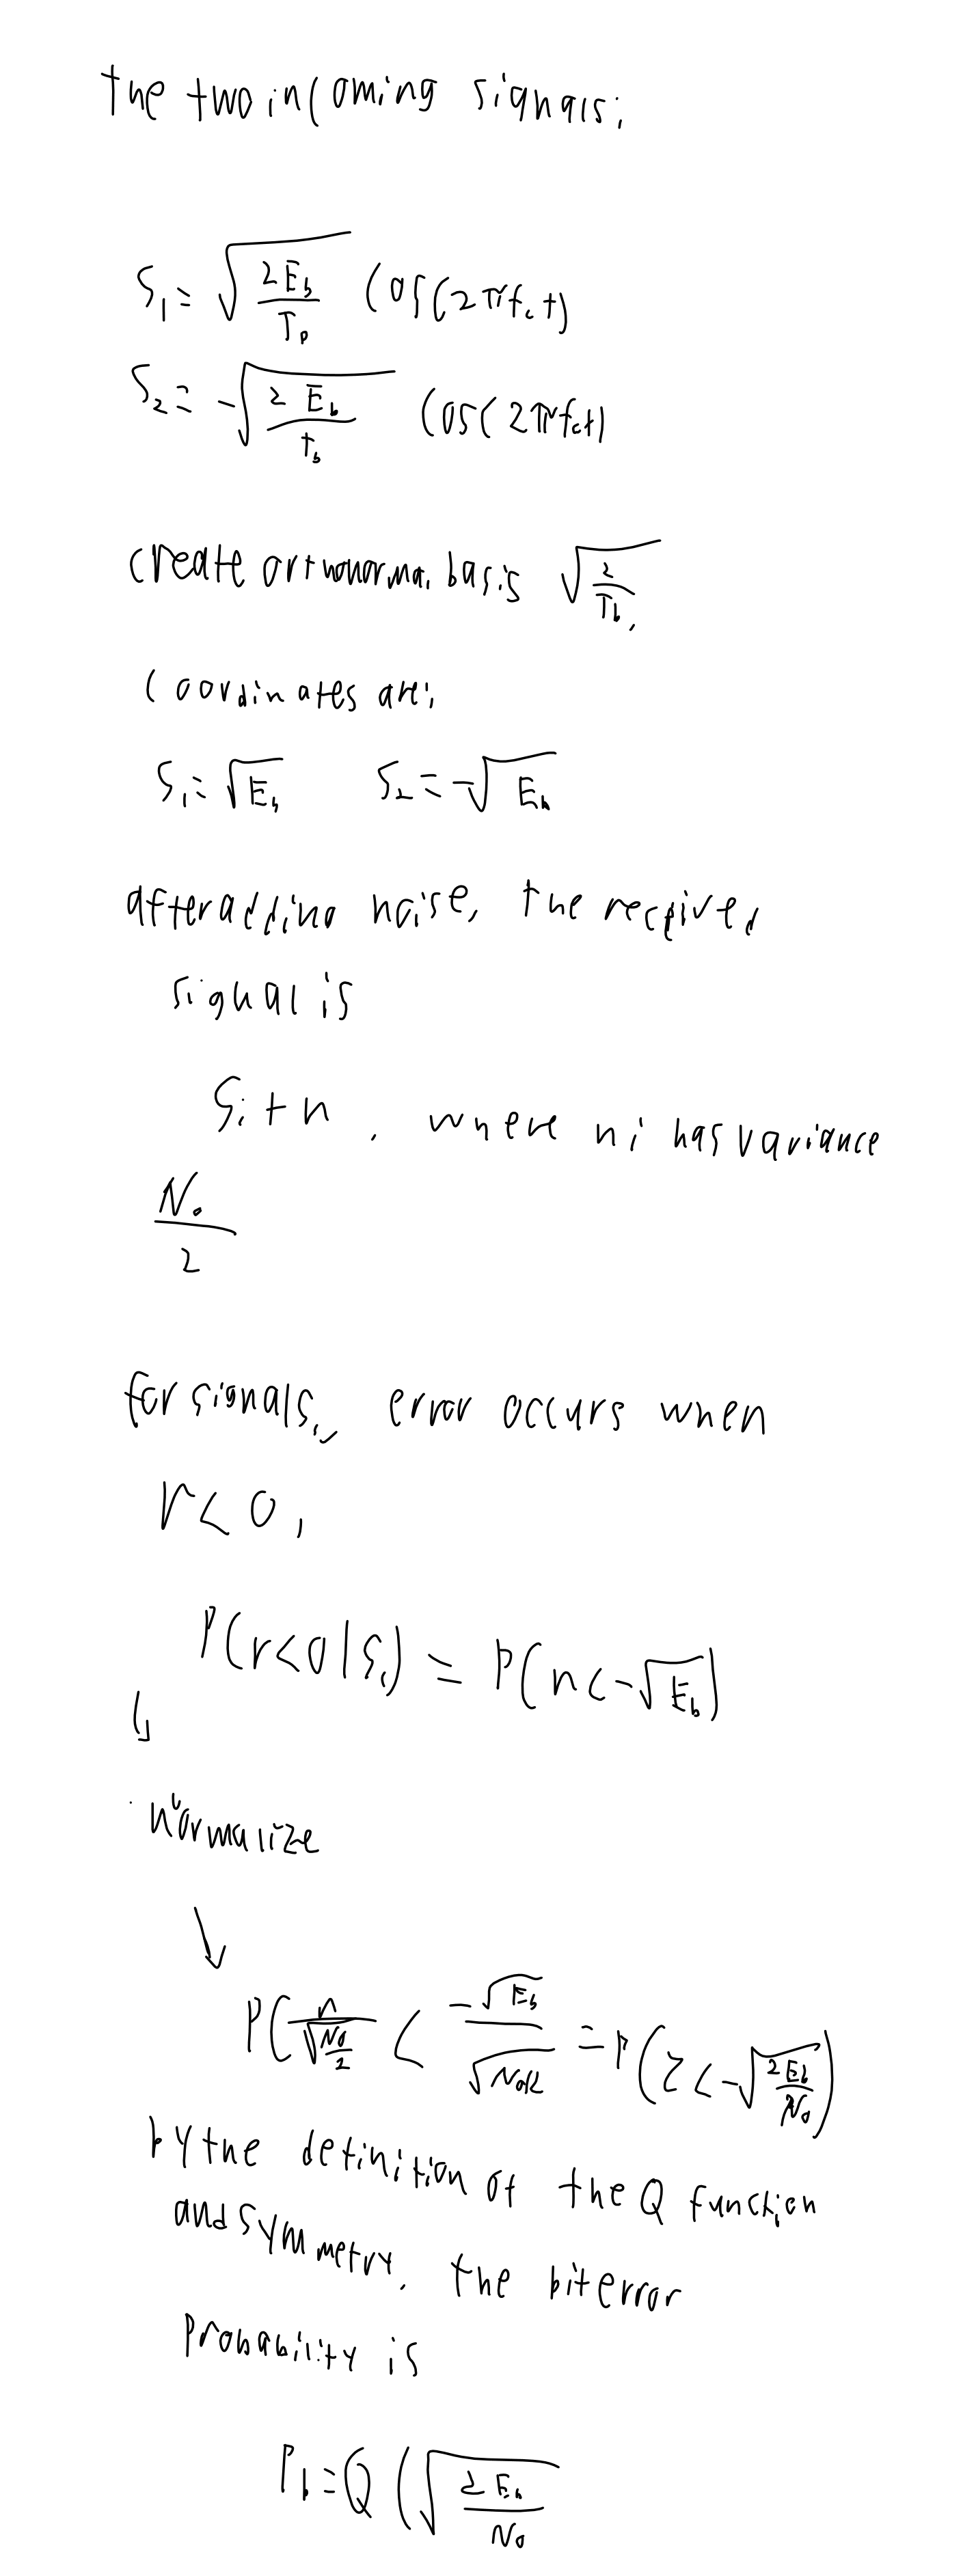


#### Question 9.1b:
We will now simulate the BPSK demodulation with AWGN, for various signal to noise ratios (SNR) (which corresponds to $E_b/N_0$), and verify whether the simulated BER vs SNR plot, matches to above calculated formula.

*Note:* In case you require to change the variable names, also change the variable names in the code section for plot, appropriately.

[0 0 1 ... 1 1 0]
[1 1 1 ... 1 1 0]
[0 0 0 ... 1 0 0]
[1 1 1 ... 0 0 1]
[0 1 1 ... 1 1 1]
[1 1 1 ... 0 0 0]
[0 0 0 ... 1 1 1]
[0 0 0 ... 0 0 1]
[1 0 0 ... 1 0 1]
[0 1 1 ... 1 0 0]
[1 0 1 ... 1 1 0]
[0 0 0 ... 0 0 1]
[0 0 0 ... 1 0 0]
[1 0 0 ... 0 0 1]
[1 1 0 ... 1 0 1]
[1 0 0 ... 1 1 0]
[1 1 1 ... 1 1 1]
[0 0 1 ... 0 0 1]
[1 0 0 ... 1 1 0]
[1 0 0 ... 1 1 0]
[0 0 0 ... 0 0 0]
[0 1 1 ... 1 1 1]
[1 0 0 ... 1 1 1]
[1 1 0 ... 0 1 1]
[1 0 0 ... 1 1 0]
[0 1 0 ... 0 1 0]
[1 1 0 ... 0 0 0]
[0 1 0 ... 0 1 0]
[1 0 1 ... 0 0 0]
[1 0 0 ... 0 1 1]
[0 1 1 ... 0 0 1]
[0 1 0 ... 0 1 1]
[0 0 1 ... 0 1 1]
[0 1 1 ... 0 0 1]
[0 1 0 ... 1 0 0]
[0 1 0 ... 1 0 0]
[1 1 0 ... 1 1 1]
[0 0 0 ... 1 1 0]
[0 0 0 ... 0 1 1]
[1 1 0 ... 0 0 1]
[1 1 0 ... 0 0 1]
[0 0 0 ... 0 0 1]
[1 0 1 ... 0 1 0]
[0 0 0 ... 1 1 1]
[1 0 0 ... 1 0 0]
[1 1 0 ... 1 1 1]
[1 0 1 ... 1 1 1]
[1 1 0 ... 1 1 1]
[0 0 1 ... 1 1 0]
[0 0 0 ... 1 1 0]
[0 0 0 ... 1 1 0]


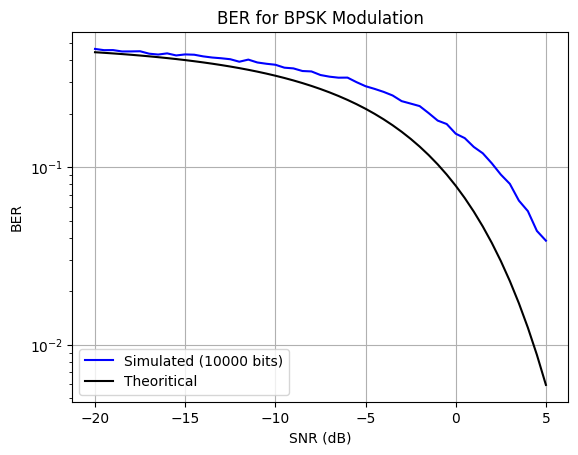

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as sps

num_bits = int(1e4) # enter number of bits
noise_mean = 0 # zero mean AWGN
noise_var = 4 # set variance of AWGN

# array of signal to noise ratio (SNR) values in decibels (dB) with 0.5 spacing
snr_db = np.arange(start = -20, stop = 5 + 0.5, step = 0.5)

sig_pwr = 10**(snr_db/10) * noise_var # signal power = snr*noise_var
ber = np.zeros(len(snr_db)) # Bit Error Rate array

for i in range(len(snr_db)):
    # randomly (uniform) generated bits
    bits = np.random.randint(2, size=num_bits)
    print(bits)
    
    # ---Modulation--- 
    symbols = np.where(bits == 1, np.sqrt(sig_pwr[i]), -np.sqrt(sig_pwr[i]))
    
    # add gaussian noise to symbols
    rx_symbols = symbols + np.random.normal(noise_mean, np.sqrt(noise_var), num_bits)
    
    # ---Demodulation---
    demod_bits = np.where(rx_symbols > 0, 1, 0)
    
    # calculating BER for the particular value of SNR
    ber[i] = np.mean(bits != demod_bits)

plt.figure()
# enter the theoritical BER below
# you may require the 'erfc' function available in the 'scipy' library
plt.semilogy(snr_db, ber, 'b', snr_db, 0.5*sps.erfc(np.sqrt(10**(snr_db/10))), 'k')
# plt.xlim(left = -20, right = 5)
# plt.ylim(bottom = 1e-3, top = 1)
plt.title('BER for BPSK Modulation')
plt.xlabel('SNR (dB)')
plt.ylabel('BER')
plt.legend(['Simulated (%i bits)' % num_bits, 'Theoritical'])
plt.grid()

### Exercise 9.2: BER calculation for 8PAM

*Source:* Michael Rice, *Digital Communications: A Discrete-Time Approach*, Second Edition, 2020. Problem 6.2.

Show that the probability of bit error for 8PAM with AWGN is $P_b = \frac{7}{12} Q(\sqrt{\frac{2}{7} \frac{E_s}{3 N_0}})$, where $E_s$ is the average energy per symbol. Assume that Gray coding is used for symbol mapping, and that all symbols are equally likely.

*Hint:* First calculate the average probability of symbol error and then check page 311 in the book to further derive the probabilty of bit error.


*ANSWER:*

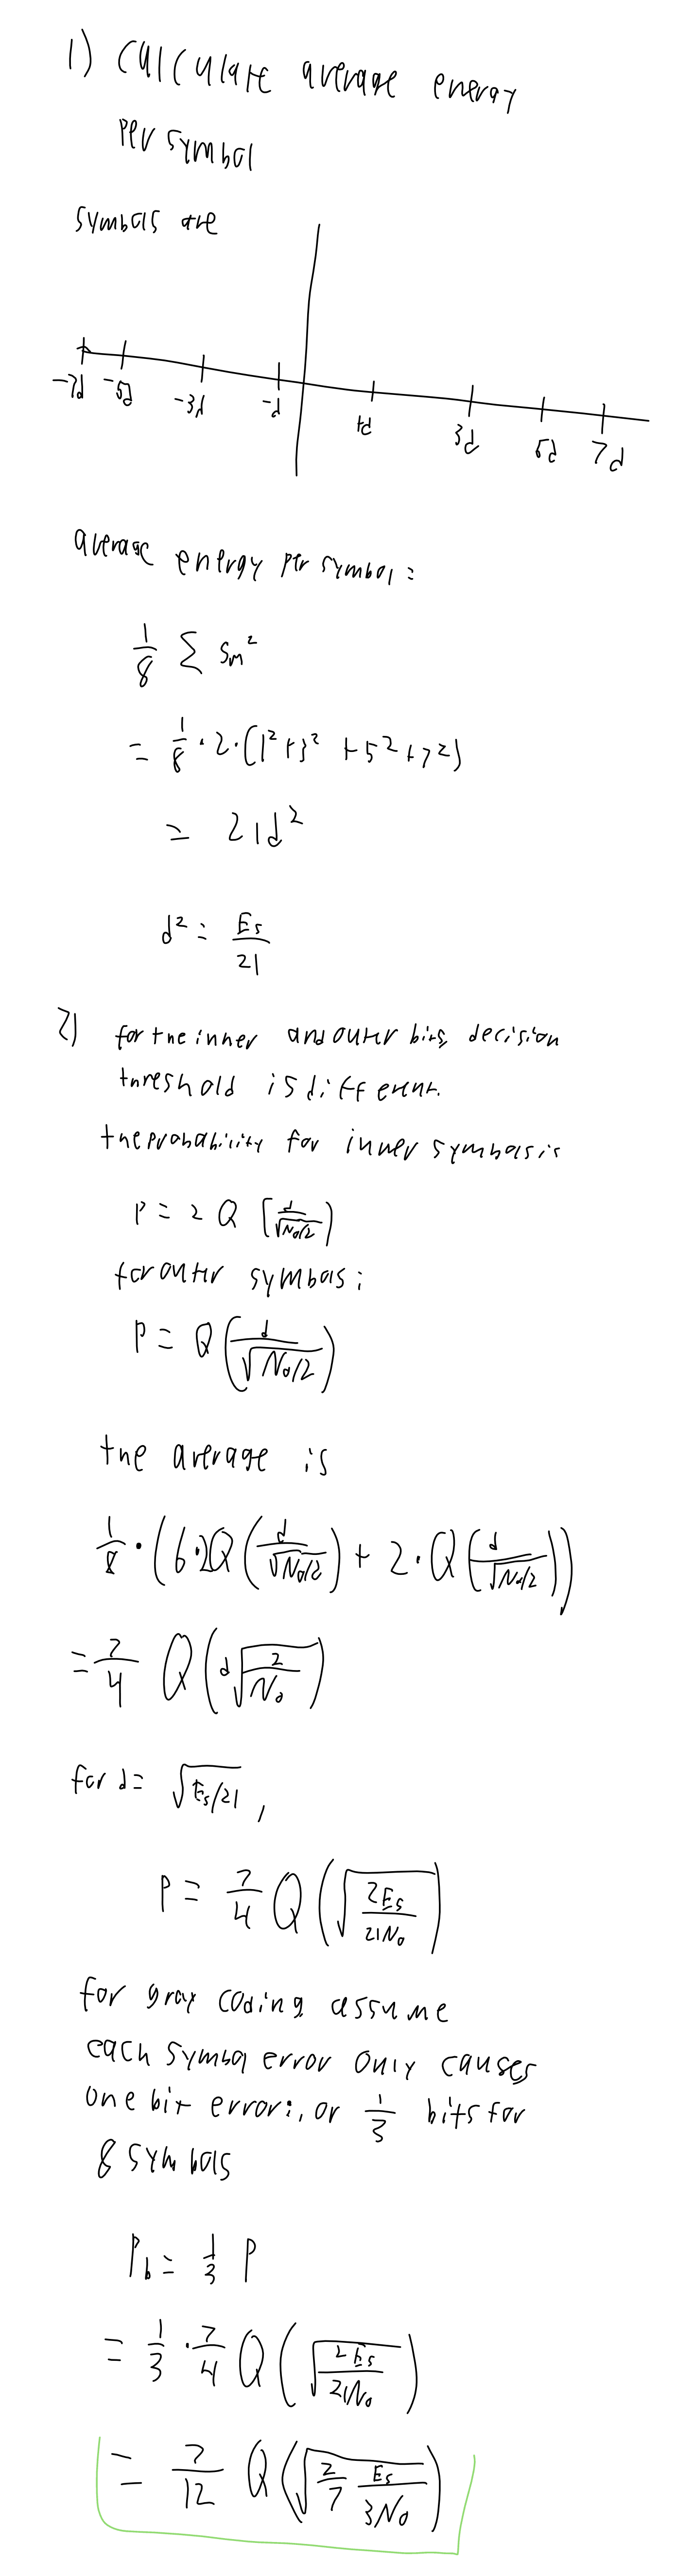